**The Objective of this notebook to give introduction to the use of Gottesman-Knill theorem and what it is used for**

Mostly the topics include

- Clifford gates
- Universal gate set
- Basic Understanding of stabilizer
- Basic Rules of The stabilizer formalism in (Not full tableau representation)

This notebook requires prior knowledge of stabilizers and clifford gates (The explanation here is just a rundown of the important things you need to remember about stabilizer and clifford gates)

# Introduction

## Clifford Gates and Universal Gate Sets



A unitary gate belongs to the **Clifford group** if it maps Pauli operators to Pauli operators under conjugation.

When a unitary \( U \) is applied, any operator \( N \) transforms as:

$$
N \;\longmapsto\; U N U^\dagger
$$

If the resulting operator is still a Pauli operator, then \( U \) is a Clifford gate.

A standard generating set for the Clifford group is:

$$
\mathcal{S} = \{ \text{CNOT}, \; H, \; P \}
$$

where:
- **H** is the Hadamard gate  
- **P** is the Phase gate  
- **CNOT** is the controlled-NOT gate  

These gates preserve the Pauli group under conjugation and form the foundation of the stabilizer formalism.


#### Clifford Conjugation Rules



\begin{array}{|c|c|c|}
\hline
\textbf{H} & \textbf{P} & \textbf{CNOT (control $\to$ target)} \\
\hline
HXH = Z & PXP^\dagger = Y & X \otimes I \rightarrow X \otimes X \\
\hline
HZH = X & PYP^\dagger = -X & I \otimes X \rightarrow I \otimes X \\
\hline
HYH = -Y & PZP^\dagger = Z & Z \otimes I \rightarrow Z \otimes I \\
\hline
 &  & I \otimes Z \rightarrow Z \otimes Z \\
\hline
\end{array}




### Why Are Clifford Gates Not Universal?



The Clifford set $S$ is **not** universal.

At first, this might seem surprising. After all, the set $( S $) appears to have everything:

- The Hadamard gate creates superpositions.
- CNOT, together with Hadamard, creates entanglement.
- The Phase gate introduces complex phases.

And many striking quantum protocols — teleportation, superdense coding, BB84, Shor’s 9-qubit code — can be implemented entirely with these gates.

**So what’s missing?**

If you experiment with circuits built only from CNOT, Hadamard, and Phase gates, you’ll notice a rigid structure:

- You only reach certain **discrete** states.
- Superpositions are always equal-weight.
- Phases are restricted to $( \{ \pm 1, \pm i \} $).
- The support of the state is always an affine subspace of $( \mathbb{F}_2^n $).

**Example**
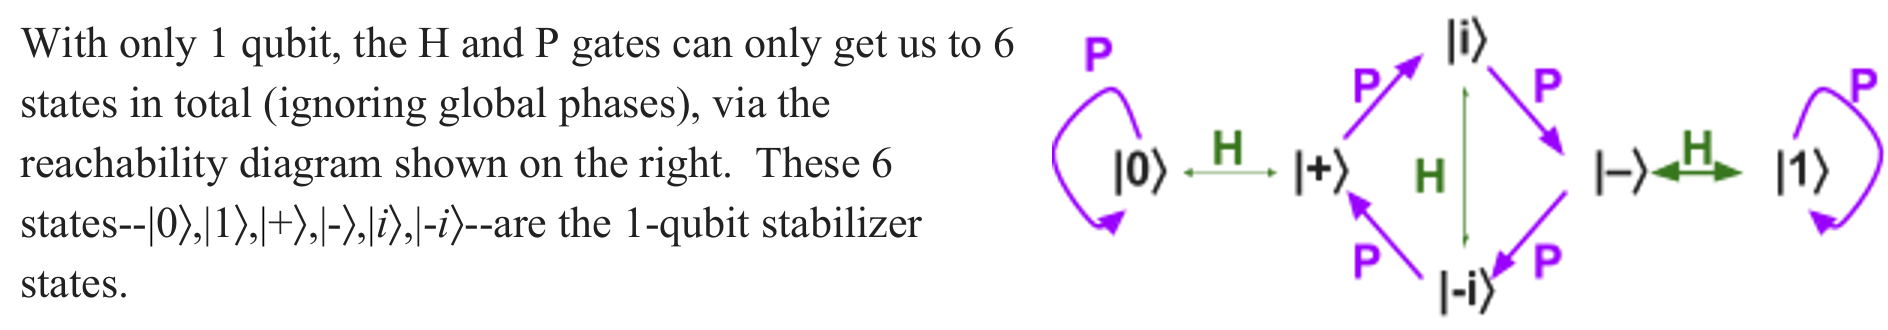


In short, Clifford gates preserve the Pauli group under conjugation.  
They keep you inside the world of **stabilizer states**.

And that world is too small.



#### Enter the T Gate

Now consider adding one more single-qubit gate:

$$
T =
\begin{pmatrix}
1 & 0 \\
0 & e^{i\pi/4}
\end{pmatrix}
$$

This is sometimes called the \( \pi/8 \) gate.

At first glance, it looks similar to the Phase gate.  
But there is a crucial difference.

Under conjugation,

$$
T X T^\dagger = \frac{X + Y}{\sqrt{2}}
$$

This is **not** a Pauli operator.

So the T gate does **not** preserve the Pauli group.

And that means it is **not** a Clifford gate.

#### Why This Changes Everything

Once we add T to the Clifford set,

$$
\{ H, P, \text{CNOT}, T \}
$$

the structure that kept us confined to stabilizer states breaks.

Now:

- Superpositions need not be equal-weight.
- Phases are no longer restricted to $ \{ \pm 1, \pm i \} $.
- States are no longer confined to affine subspaces.
- Continuous families of states become reachable.

In fact, the set $ \{ H, P, \text{CNOT}, T \} $ is **universal** for quantum computation.

The Clifford gates provide basis changes and entanglement.  
The T gate injects a non-Clifford phase that allows arbitrary unitary operations to be approximated.

Without T, quantum computation lives inside a rigid algebraic prison.  
With T, the prison walls disappear.

#### A Note on Magic State Distillation

In fault-tolerant quantum computing, stabilizer gates (Clifford gates) are often considered “cheap.”  
They can be implemented transversally in many quantum error-correcting codes and are relatively easy to protect against noise.

Non-Clifford gates like the T gate, however, are much more expensive.  
In many architectures, they cannot be implemented directly in a fault-tolerant way.

So how do we get them?

The idea is to prepare special non-stabilizer resource states — called **magic states** — such as

$$
\cos(\pi/8)\,|0\rangle + \sin(\pi/8)\,|1\rangle
$$

Using only stabilizer operations (Clifford gates, measurements, and classical feedforward), one can consume these magic states to effectively simulate a T gate.

This procedure is known as **magic state distillation**.

In practice, much of the overhead in large-scale quantum computing is devoted to producing high-quality magic states.  
Once you have them, stabilizer operations are enough to promote your circuit from the “Clifford world” to full universal quantum computation.

## Stabilizers

We say that a unitary $U$ **stabilizes** a pure state $|\Psi\rangle$ if

$$
U|\Psi\rangle = |\Psi\rangle.
$$

In other words, $|\Psi\rangle$ is an eigenstate of $U$ with eigenvalue $+1$.

Crucially, **global phase matters** here.  
If $U|\Psi\rangle = -|\Psi\rangle$, then $U$ does *not* stabilize $|\Psi\rangle$.

#### The Stabilizer Group

If $U$ and $V$ both stabilize $|\Psi\rangle$, then:

- $UV$ and $VU$ also stabilize $|\Psi\rangle$,
- $U^{-1}$ and $V^{-1}$ also stabilize $|\Psi\rangle$,
- The identity $I$ stabilizes everything.

Therefore, the set of all unitaries that stabilize $|\Psi\rangle$ forms a **group under multiplication**.

This group is called the **stabilizer group** of $|\Psi\rangle$.


### The Pauli Matrices

The next ingredient we need is the **Pauli matrices**. They are:

$$
I = \begin{pmatrix}1 & 0 \\ 0 & 1\end{pmatrix},
\quad
X = \begin{pmatrix}0 & 1 \\ 1 & 0\end{pmatrix},
\quad
Y = \begin{pmatrix}0 & -i \\ i & 0\end{pmatrix},
\quad
Z = \begin{pmatrix}1 & 0 \\ 0 & -1\end{pmatrix}.
$$

These matrices correspond exactly to the types of errors that occur in quantum error correction



### Algebraic Structure

The Pauli matrices satisfy the identities:

- $X^2 = Y^2 = Z^2 = I$
- $XY = iZ$, $YX = -iZ$
- $YZ = iX$, $ZY = -iX$
- $ZX = iY$, $XZ = -iY$


All four Pauli matrices are both **unitary** and **Hermitian**.

### What Does Each Pauli Stabilize?

- $I$ stabilizes everything.
- $-I$ stabilizes nothing (global phase matters!).

More interestingly:

- $X$ stabilizes $|+\rangle$
- $-X$ stabilizes $|-\rangle$
- $Z$ stabilizes $|0\rangle$
- $-Z$ stabilizes $|1\rangle$
- $Y$ stabilizes $|i\rangle$
- $-Y$ stabilizes $|-i\rangle$

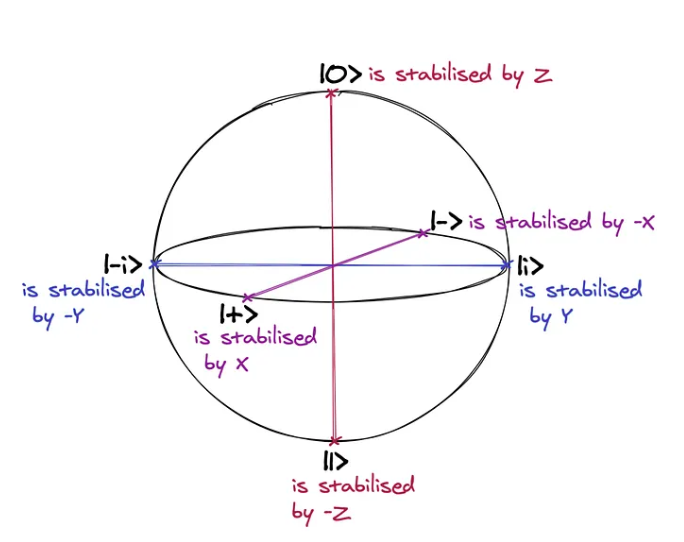

**So each of the six 1-qubit stabilizer states corresponds to a Pauli operator that stabilizes it.**

### n-Qubit Stabilizer Groups

Given an $n$-qubit pure state $|\Psi\rangle$, we define its **stabilizer group** as:

> The group of all tensor products of Pauli matrices that stabilize $|\Psi\rangle$.

Since:
- Pauli operators are closed under multiplication, and
- Stabilization is preserved under multiplication,

the stabilizer group is indeed a group.

In fact, stabilizer groups are **abelian**.

### Examples


#### Single Qubit

- The stabilizer group of $|0\rangle$ is $\{ I, Z \}$.
- The stabilizer group of $|+\rangle$ is $\{ I, X \}$.


#### Two Qubits

For $|0\rangle \otimes |+\rangle$, the stabilizer group is the Cartesian product:

$$
\{ I \otimes I, \; I \otimes X, \; Z \otimes I, \; Z \otimes X \}.
$$

By convention, we omit tensor symbols and write this as:

$$
\{ II, IX, ZI, ZX \}.
$$



#### Bell State Example

Consider the Bell state:

$$
\frac{|00\rangle + |11\rangle}{\sqrt{2}}.
$$

We can check:

- $XX$ stabilizes it,
- $-YY$ stabilizes it,
- and multiplying them gives $ZZ$.

Thus its stabilizer group is:

$$
\{ II, XX, -YY, ZZ \}.
$$

Similarly, the state

$$
\frac{|00\rangle - |11\rangle}{\sqrt{2}}
$$

has stabilizer group:

$$
\{ II, -XX, YY, ZZ \}.
$$



### Conclusion

Here is a deep and beautiful result:
- The $n$-qubit stabilizer states are **exactly** the states whose stabilizer group has size $2^n$.

So:
- 1-qubit stabilizer states have stabilizer groups of size 2.
- 2-qubit stabilizer states have stabilizer groups of size 4.
- In general, $n$-qubit stabilizer states have stabilizer groups of size $2^n$.


# How Much Information Does a Stabilizer State Require?

Suppose we describe an $n$-qubit stabilizer state using a generating set for its stabilizer group.

How many bits does it take to store this information in a classical computer?

- There are $n$ generators.
- Each generator is a tensor product of $n$ Pauli operators.
- Each Pauli ($I, X, Y, Z$) can be specified using **2 bits**.
- Additionally, we need **1 extra bit** to record the overall $\pm$ sign.

So each generator requires:

$$
2n + 1 \text{ bits}
$$

Since there are $n$ generators, the total number of bits required is:

$$
n(2n + 1) = 2n^2 + n = O(n^2).
$$



### Compare This to the Naïve Description

If we stored the full amplitude vector of an $n$-qubit state, we would need: $\sim 2^n$

complex amplitudes.

That’s exponential in $n$.

By contrast, the stabilizer description requires only $O(n^2)$ bits.

This is an **exponential compression**.

We are already starting to see the power of the stabilizer formalism.

# The Gottesman–Knill Theorem

Around 1998, Daniel Gottesman and Manny Knill proved a remarkable result:

> **Gottesman–Knill Theorem:**  
> There exists a polynomial-time classical algorithm to simulate any stabilizer circuit acting on a stabilizer initial state such as $|00\ldots0\rangle$.

Here, “simulate” means essentially anything you might want:

- Compute the probability of any sequence of measurement outcomes.
- Sample measurement outcomes (given access to classical randomness).
- Track the evolution of the quantum state throughout the circuit.


### A Consequence

A more sobering interpretation is this:

> Stabilizer states and Clifford gates, by themselves, cannot produce superpolynomial quantum speedups.

In other words, everything that can be done with only stabilizer operations can also be done efficiently on a classical computer.


## How Does the Simulation Work?

The idea is surprisingly simple:

At every step of the computation, we keep track of a **list of generators** for the current stabilizer group.

Whenever a gate is applied — CNOT, Hadamard, Phase, or a measurement — we simply update this list according to fixed algebraic rules.

We never need to store the full $2^n$-dimensional state vector.

This generator-tracking procedure is the core of the classical simulation algorithm.


# How Does the Gottesman–Knill Algorithm Work?

For simplicity, assume the initial state is

$$
|00\ldots0\rangle.
$$

The first step is to find a **stabilizer representation** — that is, a generating set for its stabilizer group.

Since $|0\rangle$ is a $+1$ eigenstate of $Z$, a valid generating set is:

$$
ZIII\ldots I \\
IZII\ldots I \\
IIZI\ldots I \\
\vdots \\
IIII\ldots Z
$$

We do not explicitly include $II\ldots I$ — it is implied.

## Tableau Representation

For algorithmic purposes, it is convenient to rewrite the generating set in matrix form.

We keep track of:

- An $n \times n$ binary **X matrix**
- An $n \times n$ binary **Z matrix**
- (Optionally) $n$ sign bits

Each row corresponds to one stabilizer generator.

A 1 in:

- The X matrix means the generator has an $X$ or $Y$ on that qubit.
- The Z matrix means the generator has a $Z$ or $Y$ on that qubit.

For example, the tableau for $|0000\rangle$ is:

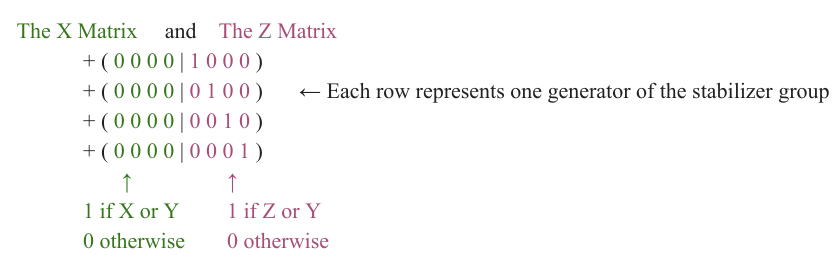

This represents the generators:

$$
\{ ZIII, IZII, IIZI, IIIZ \}.
$$

**NOTE**

Tracking $\pm$ signs is possible but slightly technical.

If we ignore signs:

- We can determine whether a measurement outcome is **deterministic or random**.
- But we cannot determine *which* deterministic outcome occurs.

For many structural purposes, ignoring signs is sufficient.

## Tableau Update Rules
We now describe how to update the tableau under Clifford gates.

---

### 1. To apply Hadamard on qubit i

Swap $i$'th column of the X matrix with $i$'th column of the Z matrix.

Intuition: Hadamard swaps the $X$ and $Z$ bases.

---

### 2. To apply Phase (P) on qubit i

Bitwise XOR column $i$ of the X matrix into column $i$ of the Z matrix.

That is:

$$
Z_i \leftarrow Z_i \oplus X_i
$$

Notice that $P$ does nothing to the initial $|00\ldots0\rangle$ tableau.



---

### 3. To apply CNOT from qubit i(control) to qubit j(target)

1. XOR column $i$ of X into column $j$ of X:

$$
X_j \leftarrow X_j \oplus X_i
$$

2. XOR column $j$ of Z into column $i$ of Z:

$$
Z_i \leftarrow Z_i \oplus Z_j
$$

This matches the propagation rules:

- $X$ spreads forward (control → target)
- $Z$ spreads backward (target → control)


### Measurement Rule

When measuring qubit $i$ in the $\{|0\rangle, |1\rangle\}$ basis:

- The outcome is **deterministic** (only one outcome is possible)  
  if and only if column $i$ of the X matrix is all zeros.

Otherwise, the outcome is random.

(Full update rules for the random case exist but are more involved.)



#### A Structural Insight

The number of computational basis states with nonzero amplitude is:

$$
2^k
$$

where $k = \text{rank}(X)$.

For the initial state, $\text{rank}(X)=0$,  
so the state contains only one basis vector: $|0000\rangle$.

### Example Evolution

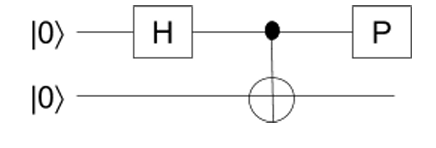

Start with 2 qubits:

$$
\begin{pmatrix}
0 & 0 \; | \; 1 & 0 \\
0 & 0 \; | \; 0 & 1
\end{pmatrix}
$$

This corresponds to generators $\{ ZI, IZ \}$.



### After Hadamard on qubit 1

Swap first X and Z columns:

$$
\begin{pmatrix}
1 & 0 \; | \; 0 & 0 \\
0 & 0 \; | \; 0 & 1
\end{pmatrix}
$$

This corresponds to generators $\{ XI, IZ \}$,  
which stabilize $|0\rangle \otimes |+\rangle$.


### After CNOT (1 → 2)

- XOR X column 1 into column 2
- XOR Z column 2 into column 1

Result:

$$
\begin{pmatrix}
1 & 1 \; | \; 0 & 0 \\
0 & 0 \; | \; 1 & 1
\end{pmatrix}
$$

This corresponds to generators $\{ XX, ZZ \}$ —  
the Bell pair stabilizers.



### After Phase on qubit 1

XOR column 1 of X into column 1 of Z:

$$
\begin{pmatrix}
1 & 1 \; | \; 1 & 0 \\
0 & 0 \; | \; 1 & 1
\end{pmatrix}
$$

This corresponds to the state:

$$
\frac{|00\rangle + i|11\rangle}{\sqrt{2}}.
$$



# Summary of the Algorithm

To classically simulate a stabilizer circuit:

1. Initialize the tableau for $|00\ldots0\rangle$.
2. For each Clifford gate, update the tableau using the algebraic rules.
3. For measurements, check the X column to determine determinism.
4. Never store the full $2^n$ state vector.

The entire evolution can be tracked using only $O(n^2)$ memory and polynomial time.

This is the core of the Gottesman–Knill algorithm.

# References
1. [Scott Aaronson's](https://www.scottaaronson.com/) "Introduction to Quantum Information Science (undergraduate, 2016)" [lecture 28-Stabilizer Formalism](https://www.scottaaronson.com/qclec/28.pdf)
2. D. Gottesman, talk at International Conference on Group Theoretic Methods in Physics (1998)-[The Heisenberg Representation of Quantum Computers by Daniel Gottesman](https://arxiv.org/pdf/quant-ph/9807006)
3. Dave Bacon's [CSE 599d- Quantum Computing Stabilizer Quantum Error Correcting Codes](https://drive.google.com/file/d/1-yhu7cpfYuZppqwMOKNJF5c3FhBR289k/view?usp=sharing)
4. Improved Simulation of Stabilizer Circuits by Scott Aaronson, Daniel Gottesman[(CHP Simulator)](https://arxiv.org/pdf/quant-ph/0406196)
5. Explore The Clifford Group, A Crucial Tool For Benchmarking, Error Correction, And More By [Abby Mitchell](https://medium.com/qiskit/explore-the-clifford-group-a-crucial-tool-for-benchmarking-error-correction-and-more-b9fdca16bb46)
   